## Part 1: Chicago Taxi Fare Prediction

**Dataset:** [City of Chicago — Taxi Trips](https://data.cityofchicago.org/Transportation/Taxi-Trips/wrvz-psew)
(Socrata Open Data / SODA API, dataset id `wrvz-psew`)

The full dataset has 100M+ rows, so instead of downloading the whole CSV we pull a
manageable sample directly from the Socrata API using a SoQL query.(internet access required).


In [ ]:
!pip install -q pandas scikit-learn matplotlib requests

In [ ]:
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
# ---- Pull a sample of the Chicago Taxi Trips dataset via the Socrata API ----
# Dataset landing page: https://data.cityofchicago.org/Transportation/Taxi-Trips/wrvz-psew
# API endpoint (JSON):  https://data.cityofchicago.org/resource/wrvz-psew.json

BASE_URL = "https://data.cityofchicago.org/resource/wrvz-psew.json"

# SoQL query: pull only the columns we need, filter out null/zero fares & distances,
# and limit to a workable sample size (50,000 rows).
params = {
    "$select": "trip_seconds,trip_miles,fare,trip_start_timestamp",
    "$where": "fare > 0 AND trip_miles > 0 AND trip_seconds > 0",
    "$limit": 50000
}

response = requests.get(BASE_URL, params=params)
response.raise_for_status()
data = pd.DataFrame(response.json())
print(data.shape)
data.head()

(50000, 4)


,trip_seconds,trip_miles,fare,trip_start_timestamp
0,65,0.04,3.5,2023-12-31T23:45:00.000
1,2305,12.63,37,2023-12-31T23:45:00.000
2,600,1.1,7.5,2023-12-31T23:45:00.000
3,1323,12.94,33.25,2023-12-31T23:45:00.000
4,1,0.04,40,2023-12-31T23:45:00.000


In [ ]:
data['trip_seconds'] = pd.to_numeric(data['trip_seconds'], errors='coerce')
data['trip_miles']   = pd.to_numeric(data['trip_miles'], errors='coerce')
data['fare']         = pd.to_numeric(data['fare'], errors='coerce')

data.isnull().sum()

,0
trip_seconds,0
trip_miles,0
fare,0
trip_start_timestamp,0


In [ ]:
data = data.dropna(subset=['trip_seconds', 'trip_miles', 'fare'])

data = data[(data['fare'] < 200) & (data['trip_miles'] < 100) & (data['trip_seconds'] < 3*3600)]
print(data.shape)
data.describe()

(49939, 4)


,trip_seconds,trip_miles,fare
count,49939.000000,49939.000000,49939.000000
mean,1177.966519,6.985545,22.207705
std,836.113374,6.699150,15.735655
min,1.000000,0.010000,1.000000
25%,540.000000,1.200000,8.750000
50%,1003.000000,4.220000,18.250000
75%,1628.000000,12.000000,33.500000
max,10716.000000,78.170000,180.250000


In [ ]:
x = data[['trip_miles', 'trip_seconds']].values
y = data['fare'].values

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print(x_train.shape, x_test.shape)

(39951, 2) (9988, 2)


In [ ]:
model = LinearRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

print('Coefficients (trip_miles, trip_seconds):', model.coef_)
print('Intercept:', model.intercept_)

Coefficients (trip_miles, trip_seconds): [1.60132396 0.00573458]
Intercept: 4.264520050570326


In [ ]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print('MSE  :', mse)
print('RMSE :', rmse)
print('R2   :', r2)

MSE  : 38.8082476509017
RMSE : 6.2296266060576775
R2   : 0.8429746333999311


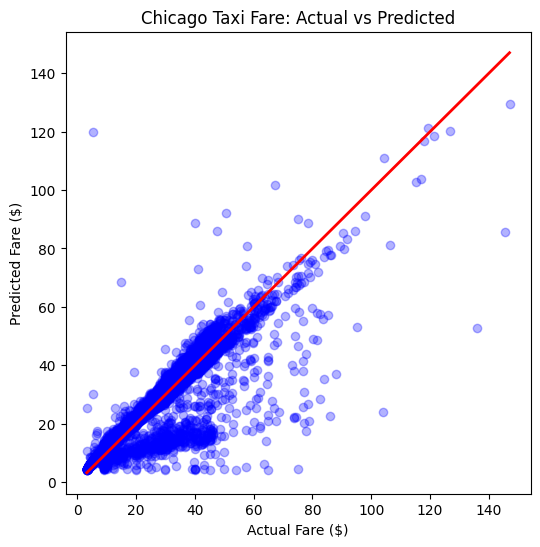

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.3, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linewidth=2)
plt.title('Chicago Taxi Fare: Actual vs Predicted')
plt.xlabel('Actual Fare ($)')
plt.ylabel('Predicted Fare ($)')
plt.show()

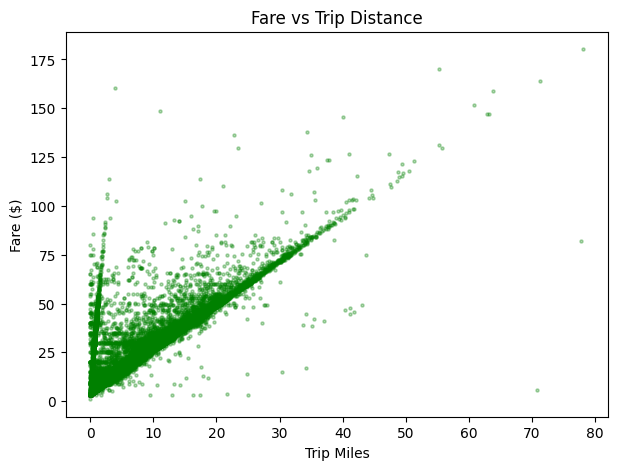

In [ ]:
plt.figure(figsize=(7,5))
plt.scatter(data['trip_miles'], data['fare'], s=5, alpha=0.3, color='green')
plt.title('Fare vs Trip Distance')
plt.xlabel('Trip Miles')
plt.ylabel('Fare ($)')
plt.show()

---
## Part 2: Predicting Body Weight (Height, Age, Gender)

**Dataset:** the 10-row sample table from the Lab Activity Book (Section 5.8, Exercise 2).
A ready-to-use CSV (`weight_dataset.csv`) is provided alongside this notebook — in Colab,
upload it via the Files panel, or recreate it with the code below.


In [ ]:
weight_data = {
    'Weight': [79, 69, 73, 95, 82, 55, 69, 71, 64, 69],
    'Height': [1.80, 1.68, 1.82, 1.70, 1.87, 1.55, 1.50, 1.78, 1.67, 1.64],
    'Age':    [35, 39, 25, 60, 27, 18, 89, 42, 16, 52],
    'Gender': ['Male','Male','Male','Male','Male','Female','Female','Female','Female','Female']
}
data2 = pd.DataFrame(weight_data)


data2

,Weight,Height,Age,Gender
0,79,1.80,35,Male
1,69,1.68,39,Male
2,73,1.82,25,Male
3,95,1.70,60,Male
4,82,1.87,27,Male
5,55,1.55,18,Female
6,69,1.50,89,Female
7,71,1.78,42,Female
8,64,1.67,16,Female
9,69,1.64,52,Female


In [ ]:
data2.isnull().sum()

,0
Weight,0
Height,0
Age,0
Gender,0


In [ ]:
data2['Gender'] = data2['Gender'].map({'Male': 1, 'Female': 0})
data2

,Weight,Height,Age,Gender
0,79,1.80,35,1
1,69,1.68,39,1
2,73,1.82,25,1
3,95,1.70,60,1
4,82,1.87,27,1
5,55,1.55,18,0
6,69,1.50,89,0
7,71,1.78,42,0
8,64,1.67,16,0
9,69,1.64,52,0


In [ ]:
x2 = data2[['Height', 'Age', 'Gender']].values
y2 = data2['Weight'].values

x2_train, x2_test, y2_train, y2_test = train_test_split(x2, y2, test_size=0.2, random_state=42)
print(x2_train.shape, x2_test.shape)

(8, 3) (2, 3)


In [ ]:

model2 = LinearRegression()
model2.fit(x2_train, y2_train)
y2_pred = model2.predict(x2_test)

print('Predicted:', y2_pred)
print('Actual   :', y2_test)

Predicted: [56.85651025 79.10576115]
Actual   : [64 69]


In [ ]:
mse2 = mean_squared_error(y2_test, y2_pred)
rmse2 = np.sqrt(mse2)
r2_2 = r2_score(y2_test, y2_pred)

print('MSE  :', mse2)
print('RMSE :', rmse2)
print('R2   :', r2_2)

print('\nCoefficients [Height, Age, Gender]:', model2.coef_)
print('Intercept:', model2.intercept_)

MSE  : 76.57792714844265
RMSE : 8.750881506936468
R2   : -11.252468343750825

Coefficients [Height, Age, Gender]: [32.8353363   0.31729474 14.62311848]
Intercept: -3.0552172392595196


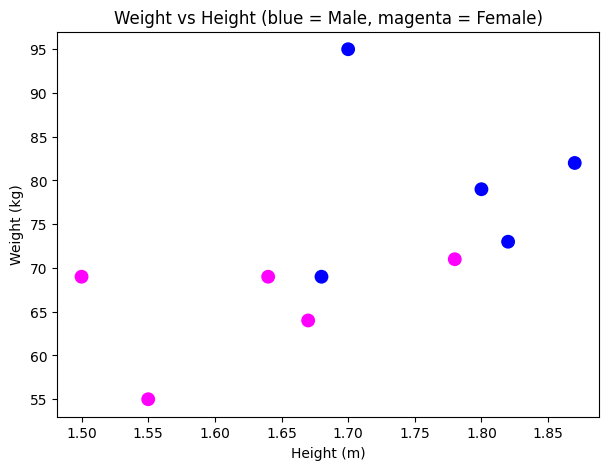

In [ ]:
plt.figure(figsize=(7,5))
colors = data2['Gender'].map({1: 'blue', 0: 'magenta'})
plt.scatter(data2['Height'], data2['Weight'], c=colors, s=80)
plt.title('Weight vs Height (blue = Male, magenta = Female)')
plt.xlabel('Height (m)')
plt.ylabel('Weight (kg)')
plt.show()

In [ ]:
new_person = np.array([[1.75, 30, 1]])
predicted_weight = model2.predict(new_person)
print(f'Predicted weight: {predicted_weight[0]:.2f} kg')

Predicted weight: 78.55 kg
